In [1]:
import torch
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

import torch.nn as nn
import torch.nn.functional as F

import torch.optim as optim
from requests.packages import target
from sympy.codegen.ast import none
from torch.utils.data import dataloader
from torch.utils.data import random_split, DataLoader
import threading
import copy
from Classe_agent import Agent


# PyTorch CNN

https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html

We will do the following steps in order:

1.Load and normalize the CIFAR10 training and test datasets using torchvision

2.Define a Convolutional Neural Network

3.Define a loss function

4.Train the network on the training data

5.Test the network on the test data

In [2]:
# --- hyperparamètres ---

RANDOM_SEED = 123
BATCH_SIZE = 10
NUM_EPOCHES = 100

MOMENTUM = 0.9
LEARING_RATE = 0.001
SCALE = 0.1
IMG_SIZE = (128, 128)
LATENT_DIM = 10
N_AGENT = 4
# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
torch.version
torch.version.cuda
torch.cuda.is_available()

True

In [4]:
transform = transforms.Compose(
            [transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])


trainset = torchvision.datasets.CIFAR10(root='./data', train=True,download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE,shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE,shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat','deer', 'dog', 'frog', 'horse', 'ship', 'truck')

train_size = len(trainset)

C:\Users\flofl\PycharmProjects\IA_A_à_Z\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


# Define a Convolutional Neural Network

In [5]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
            x = self.pool(F.relu(self.conv1(x)))
            x = self.pool(F.relu(self.conv2(x)))
            x = torch.flatten(x, 1) # flatten all dimensions except batch
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            x = self.fc3(x)
            return x


In [7]:
class AlexNet(nn.Module):
    def __init__(self, num_classes):
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            # Feature extraction bloc 1
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # Bloc 2
            nn.Conv2d(64, 192, kernel_size=5, stride=1, padding=2),  # ← CORRIGÉ stride
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),


            # Bloc 3
            nn.Conv2d(192, 384, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            # Bloc 4
            nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            # Bloc 5
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Linear(6 * 6 * 256, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, num_classes),  # ← CORRIGÉ: output final
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), 256 * 6 * 6)
        logits = self.classifier(x)
        return logits

# Define a Loss function and optimizer
Let’s use a Classification Cross-Entropy loss and SGD with momentum.

# 4. Train the network

In [6]:
def synchronize_models_average(agent_list):

    # récupérer les poids du premier modèle
    avg_state_dict = copy.deepcopy(agent_list[0].model.state_dict())

    # somme des poids
    for key in avg_state_dict:

        for i in range(1, len(agent_list)):
            avg_state_dict[key] += agent_list[i].model.state_dict()[key]

        # moyenne
        avg_state_dict[key] = avg_state_dict[key] / len(agent_list)

    # appliquer les poids moyens à tous les agents
    for agent in agent_list:
        agent.model.load_state_dict(avg_state_dict)

In [7]:
def synchronize_models_cycle(agent_list):
    state_dict_list = []

    for agent in agent_list:
        state_dict = copy.deepcopy(agent.model.state_dict())
        state_dict_list.append(state_dict)

    for e,agent in enumerate(agent_list):
        agent.model.load_state_dict(state_dict_list[(e+1) % len(agent_list)])


    # Charger les nouveaux poid



In [8]:
datasets_list = []
trainloaders_list = []
net_list = []
agent_list = []
split = train_size // N_AGENT

datasets_list = random_split(trainset, [split] * N_AGENT)#split dataset in N agent pefectly

for e in range(N_AGENT):

    trainloader = DataLoader(
        datasets_list[e],
        batch_size=BATCH_SIZE,
        shuffle=True
    )
    trainloaders_list.append(trainloader)

    net = Net().to(DEVICE)
    #net = AlexNet(len(classes)).to(DEVICE)

    net_list.append(net)

    agent = Agent(
        agent_id=e,
        net=net_list[e],
        learning_rate=0.001,
        momentum=0.9,
        trainloader=trainloaders_list[e],
        testloader=testloader,
        device=DEVICE,
        neighbors = agent_list
    )
    agent_list.append(agent)



In [ ]:
loss_validate_list = []
accuracy_validate_list = []

for epoch in range(NUM_EPOCHES):

    threads_list = []

    # THREADS
    for agent in agent_list:
        thread = threading.Thread(
            target=agent.train_and_validate,
            args=[agent_list]
        )
        threads_list.append(thread)

    # Start des deux modèles
    for thread in threads_list:
        thread.start()

    print(f"Epoch {epoch+1}/{NUM_EPOCHES}")

    # Attendre la fin
    for thread in threads_list:
        thread.join()


    # Synchronisation des poids
    synchronize_models_average(agent_list)

print("Les modèles ont fini l'entraînement")

Epoch 1/100
Agent 2 start
Agent 3 start
Agent 0 start
Agent 1 start
Model0 - Acc:16.552 % - Loss:2.2193327251434325 %
Model2 - Acc:13.056 % - Loss:2.2997202949523925 %
Model3 - Acc:10.6 % - Loss:2.3025009300231933 %
Model1 - Acc:15.256 % - Loss:2.2470164989471435 %
Epoch 2/100
Agent 0 start
Agent 2 start
Agent 1 start
Agent 3 start
Model0 - Acc:15.872 % - Loss:2.2313265575408936 %
Model2 - Acc:15.888 % - Loss:2.2307600038528443 %
Model1 - Acc:16.616 % - Loss:2.223962112045288 %
Model3 - Acc:16.448 % - Loss:2.230592947483063 %
Epoch 3/100
Agent 3 start
Agent 0 start
Agent 2 start
Agent 1 start
Model3 - Acc:22.0 % - Loss:2.0964777433395385 %
Model0 - Acc:22.432 % - Loss:2.09323995885849 %
Model2 - Acc:21.864 % - Loss:2.094074253368378 %
Model1 - Acc:22.656 % - Loss:2.0809338348388673 %
Epoch 4/100
Agent 0 start
Agent 1 start
Agent 3 start
Agent 2 start
Model0 - Acc:25.216 % - Loss:2.014643701648712 %
Model3 - Acc:24.976 % - Loss:2.024322412967682 %
Model1 - Acc:25.344 % - Loss:2.00641617

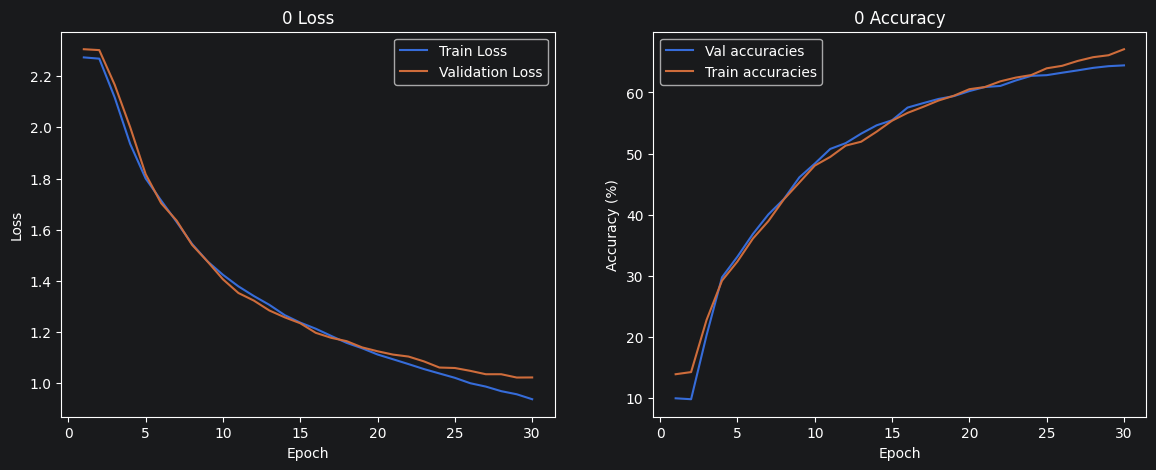

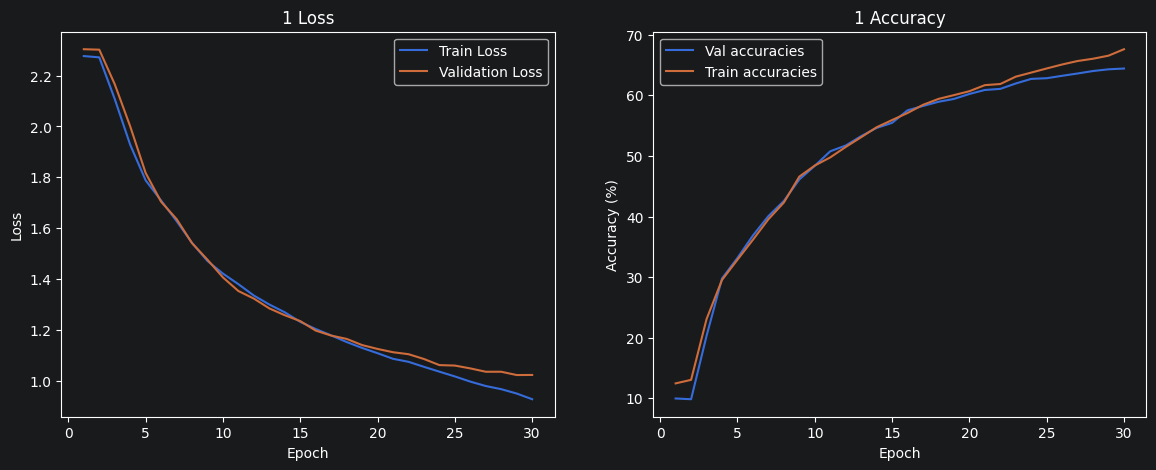

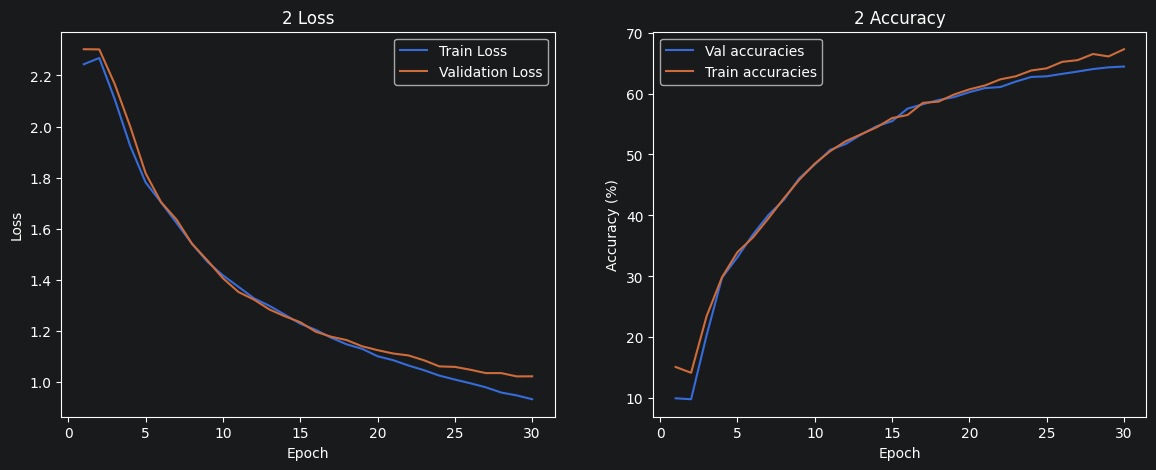

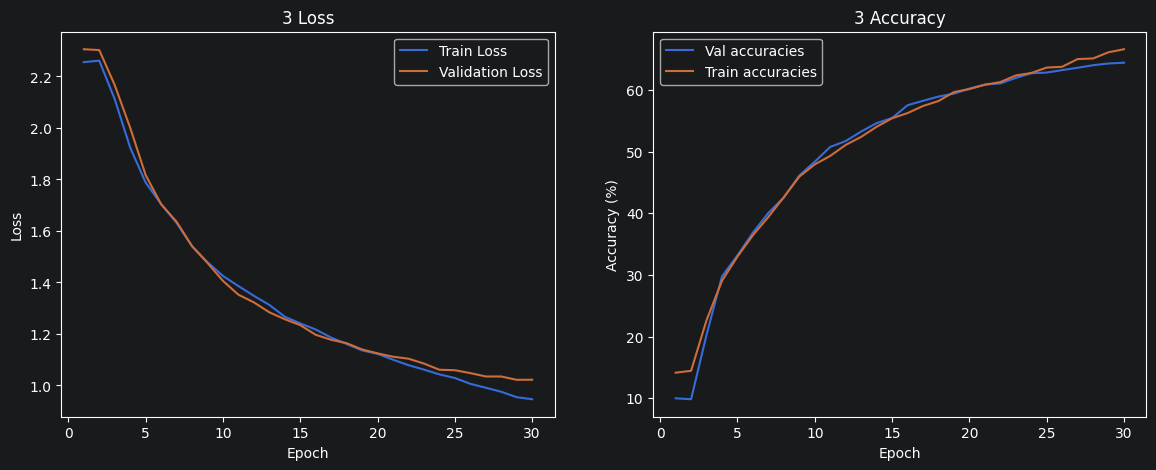

In [10]:
for agent in agent_list:
    agent.plot_metrics()

In [11]:
for agent in agent_list:
    print(agent.total_distance_list)


[[16.614960223436356, 16.277426168322563, 16.70578433573246, 16.55184654891491], [0.5961785281542689, 0.4709702297113836, 1.1051088646054268, 0.728779565077275], [0.6189080961048603, 0.4929963806644082, 0.49384190887212753, 0.47764656599611044], [0.8235374391078949, 0.6417513294145465, 0.9877866338938475, 0.5603620987385511], [0.7111294399946928, 0.7403330248780549, 0.7095229886472225, 0.731285200919956], [0.8696268508210778, 0.8324473956599832, 0.9876772360876203, 0.8350892127491534], [0.919061322696507, 0.9296218482777476, 0.9216461572796106, 0.8955856999382377], [1.0872572781518102, 1.0076603526249528, 1.0938730500638485, 1.0957125257700682], [1.176587587222457, 1.1556744975969195, 1.1973605435341597, 1.1339029390364885], [1.2827473217621446, 1.282913758419454, 1.267762734554708, 1.315060299821198], [1.3425354473292828, 1.3386382292956114, 1.3014905340969563, 1.3359846472740173], [1.4771652594208717, 1.3827638747170568, 1.3362020310014486, 1.426886253990233], [1.4780600313097239, 1.

In [12]:
def node_weight_metric(agent_list):

    avg_state_dict = copy.deepcopy(
        agent_list[0].model.state_dict()
    )

    # moyenne
    for key in avg_state_dict:

        for i in range(1, len(agent_list)):
            avg_state_dict[key] += (
                agent_list[i].model.state_dict()[key]
            )

        avg_state_dict[key] /= len(agent_list)

    # différences
    for agent_id, agent in enumerate(agent_list):

        print(f"\nAgent {agent_id}")

        total_distance = 0

        for key in avg_state_dict:

            diff = (
                avg_state_dict[key]
                - agent.model.state_dict()[key]
            )

            distance = torch.norm(diff).item()

            total_distance += distance

            print(
                f"{key:<30} "
                f"L2 distance = {distance:.6f}"
            )

        print(
            f"Distance totale = {total_distance:.6f}"
        )

In [13]:
node_weight_metric(agent_list)


Agent 0
conv1.weight                   L2 distance = 0.000000
conv1.bias                     L2 distance = 0.000000
conv2.weight                   L2 distance = 0.000000
conv2.bias                     L2 distance = 0.000000
fc1.weight                     L2 distance = 0.000000
fc1.bias                       L2 distance = 0.000000
fc2.weight                     L2 distance = 0.000000
fc2.bias                       L2 distance = 0.000000
fc3.weight                     L2 distance = 0.000000
fc3.bias                       L2 distance = 0.000000
Distance totale = 0.000000

Agent 1
conv1.weight                   L2 distance = 0.000000
conv1.bias                     L2 distance = 0.000000
conv2.weight                   L2 distance = 0.000000
conv2.bias                     L2 distance = 0.000000
fc1.weight                     L2 distance = 0.000000
fc1.bias                       L2 distance = 0.000000
fc2.weight                     L2 distance = 0.000000
fc2.bias                       L2 dis

In [14]:
def plot_all_agents_metrics(agent_list):

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ===== LOSS =====
    for agent in agent_list:

        train_epochs = range(1, len(agent.train_losses) + 1)
        val_epochs = range(1, len(agent.loss_validate_list) + 1)

        axes[0].plot(
            train_epochs,
            agent.train_losses,
            label=f"Agent {agent.id} Train"
        )

        axes[0].plot(
            val_epochs,
            agent.loss_validate_list,
            linestyle='--',
            label=f"Agent {agent.id} Val"
        )

    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # ===== ACCURACY =====
    for agent in agent_list:

        train_epochs = range(1, len(agent.train_accuracies) + 1)
        val_epochs = range(1, len(agent.accuracy_validate_list) + 1)

        axes[1].plot(
            train_epochs,
            agent.train_accuracies,
            label=f"Agent {agent.id} Train"
        )

        axes[1].plot(
            val_epochs,
            agent.accuracy_validate_list,
            linestyle='--',
            label=f"Agent {agent.id} Val"
        )

    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [15]:
for agent in agent_list:
    print("Agent",agent.id)
    #print(agent.loss_validate_list)
    print(agent.val_losses)
    #print(agent.accuracy_validate_list)
    print(agent.val_accuracies)

Agent 0
[2.305640916824341, 2.302181797027588, 2.1663057805299757, 2.0004992080926893, 1.8168922766447066, 1.7036273939609528, 1.6356246294379235, 1.5407330011725426, 1.4755443922281266, 1.4058950027227402, 1.3523136999607086, 1.3225678642988206, 1.2839671583473682, 1.2570632019042969, 1.2340472621321679, 1.1966528116166593, 1.177111526042223, 1.1639846560359002, 1.1396916945129634, 1.1244911669790745, 1.1114966116845608, 1.103839182496071, 1.0848880023658276, 1.0608620426356792, 1.0590472467243672, 1.0478630217462779, 1.0347097909599543, 1.0346906567960978, 1.0217551814615726, 1.0220832800269126]
[10.0, 9.85, 20.31, 29.78, 33.17, 36.87, 40.07, 42.57, 46.12, 48.37, 50.77, 51.72, 53.27, 54.63, 55.46, 57.53, 58.25, 58.94, 59.41, 60.23, 60.89, 61.07, 61.96, 62.72, 62.83, 63.23, 63.61, 64.02, 64.3, 64.43]
Agent 1
[2.303968032360077, 2.302181797027588, 2.1663057805299757, 2.0004992080926893, 1.8168922766447066, 1.7036273939609528, 1.6356246294379235, 1.5407330011725426, 1.4755443922281266, 

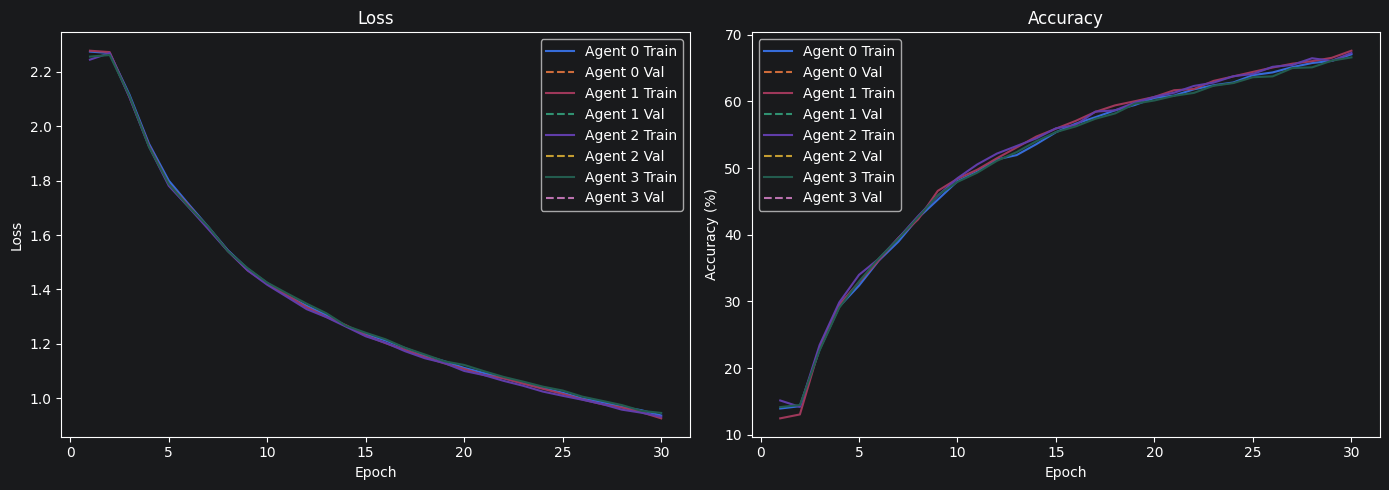

In [16]:
plot_all_agents_metrics(agent_list)

In [18]:
def plot_all_agent_node_weight_metric(agent_list):

    total_distance = range(1, len(agent.total_distance_list) + 1)

    plt.plot(
        total_distance,
        agent.total_distance_list,
        label=f"Agent {agent.id}"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Total Distance")
    plt.title("total_distance_node_weight")
    plt.legend()


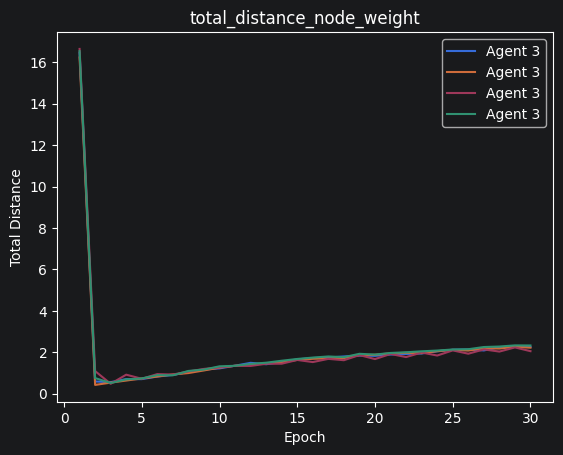

In [19]:
plot_all_agent_node_weight_metric(agent_list)

# 5. Test the network on the test data
We have trained the network for 2 passes over the training dataset. But we need to check if the network has learnt anything at all.

We will check this by predicting the class label that the neural network outputs, and checking it against the ground-truth. If the prediction is correct, we add the sample to the list of correct predictions.

Okay, first step. Let us display an image from the test set to get familiar.

dataiter = iter(testloader)

In [19]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

NameError: name 'imshow' is not defined

In [ ]:
# Après avoir entraîné ton modèle

model.eval()
with torch.no_grad():
    # Prends une image de test
    images, labels = next(iter(testloader))

    # Prédiction
    outputs = model(images[0].unsqueeze(0))

    # Afficher les scores pour les 10 classes
    for i, (classe, score) in enumerate(zip(classes, outputs[0])):
        barre = '█' * int(score * 2)  # Barre visuelle
        print(f"Neurone #{i} ({classe:5s}) : {barre} {score:.2f}")

    # La classe prédite est celle avec le score le plus élevé
    predicted = torch.argmax(outputs, dim=1)
    print(f"\n✅ Prédiction : {classes[predicted]}")
    print(f"   Vérité     : {classes[labels[0]]}")